In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
df_train = pd.read_csv('../input/train.csv')
df_train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


## Study Dependent Variable: Sales Price

In [4]:
#descriptive statistics summary
df_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice', ylabel='Count'>

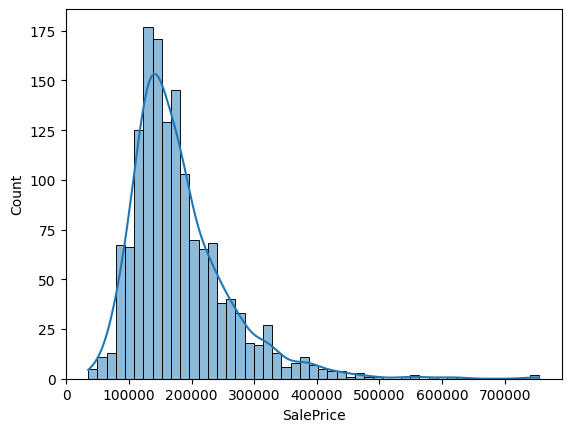

In [5]:
sns.histplot(data=df_train, x='SalePrice', kde=True)

What can we say from this plot alone?
* *<b>Deviate from the normal distribution.</b>*
* *<b>Have appreciable positive skewness.</b>*
* *<b>Show peakedness.</b>*

Let's check its `Skewness` and `Kurtosis`.

In [6]:
# Calculate skewness and kurtosis
skewness = df_train['SalePrice'].skew()
kurtosis_val = df_train['SalePrice'].kurtosis()

print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis_val:.4f}")
print("\nInterpretation:")
print(f"- Skewness: {skewness:.4f} → ", end="")
if abs(skewness) < 0.5:
    print("Approximately symmetric")
elif skewness > 0.5:
    print("Right-skewed (positively skewed) - tail extends to the right")
else:
    print("Left-skewed (negatively skewed) - tail extends to the left")

print(f"- Kurtosis: {kurtosis_val:.4f} → ", end="")
if kurtosis_val > 0:
    print("Leptokurtic (heavy tails, sharp peak)")
elif kurtosis_val < 0:
    print("Platykurtic (light tails, flat peak)")
else:
    print("Mesokurtic (normal distribution-like)")

Skewness: 1.8829
Kurtosis: 6.5363

Interpretation:
- Skewness: 1.8829 → Right-skewed (positively skewed) - tail extends to the right
- Kurtosis: 6.5363 → Leptokurtic (heavy tails, sharp peak)


Text(0.5, 1.0, 'Distribution of SalePrice (log scale)')

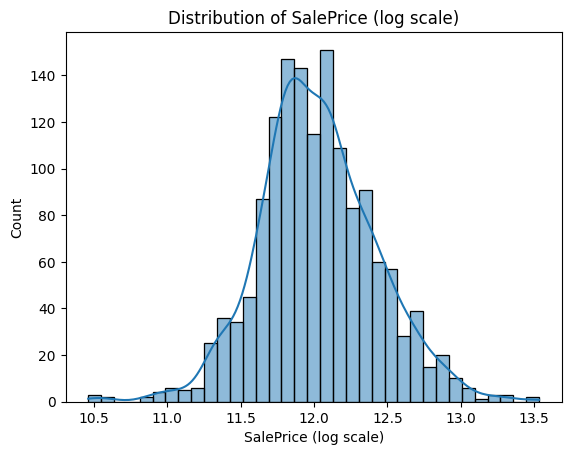

In [7]:
sns.histplot(data=np.log(df_train['SalePrice']), kde=True)
plt.xlabel('SalePrice (log scale)')
plt.title('Distribution of SalePrice (log scale)')

In [8]:
print(f"Skewness: {np.log(df_train['SalePrice']).skew():.4f}") # Approximately symmetric
print(f"Kurtosis: {np.log(df_train['SalePrice']).kurtosis():.4f}") # Roughly Mesokurtic (normal distribution-like)

Skewness: 0.1213
Kurtosis: 0.8095


### SalesPrice study results
- `Before log-transform:` SalePrice is highly right-skewed (skewness ≈ 1.88) and leptokurtic (kurtosis ≈ 6.53). This means extreme high values dominate, residuals from regression would likely be non-normal (i.e., linear regression assumes normally-distributed residuals), and model estimates could be unstable.

- `After log-transform:` Skewness dropped to ≈ 0.12 and kurtosis to ≈ 0.81, both close to a normal distribution. This stabilizes variance, reduces the influence of outliers, and makes linear regression assumptions much more valid.

In short: raw SalePrice isn’t ideal for regression, but the log-transformed version is well-behaved and ready for modeling.

You know what?  
Let's add the log-transformed `SalePrice` to the `df_train`.  Cause, why not?  
Also, let's not drop the original `SalePrice` in case we need to use it for comparison.  


In [9]:
df_train['SalePrice_log'] = np.log(df_train['SalePrice'])

## Relationship with Independent variables

### Relationship with numerical variables

First, we study the numerical variables that are most correlated with SalePrice:

- **GrLivArea**  
  - Above grade (ground) living area in square feet  
  - Strongest single predictor of SalePrice  

- **TotalBsmtSF**  
  - Total square feet of basement area  
  - Adds significant value when finished or usable  

- **LotArea**  
  - Lot size in square feet  
  - Larger lots generally increase property value  


<Axes: xlabel='GrLivArea', ylabel='SalePrice_log'>

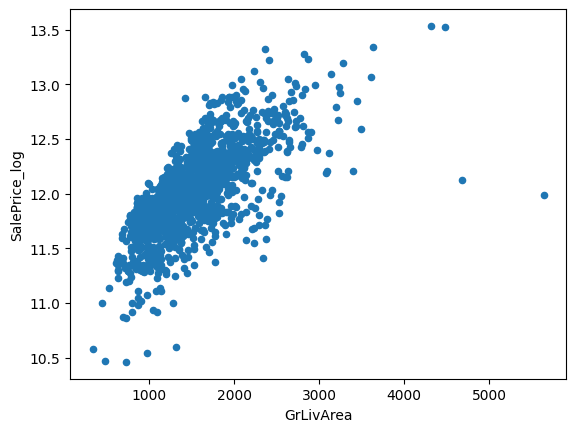

In [10]:
var = 'GrLivArea'
data = pd.concat([df_train['SalePrice_log'], df_train[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice_log')

*There's a strong positive linear relationship — as ground living area increases, log-transformed sale price tends to increase.*    

Well, I guess it is a good one, isn't it?

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice_log'>

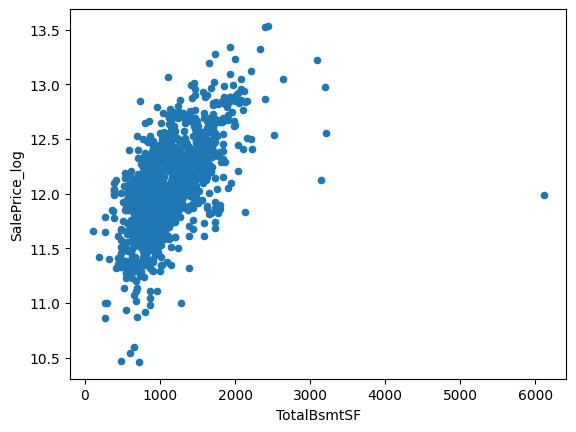

In [11]:
var = 'TotalBsmtSF'
filtered = df_train[df_train[var] != 0] # Since there are some houses without basement, we will only plot those with basement area greater than 0
data = pd.concat([filtered['SalePrice_log'], filtered[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice_log')


*There's a positive relationship: as basement area increases, log-transformed sale price tends to increase. The pattern is roughly linear, though slightly more scattered than GrLivArea.*

<Axes: xlabel='LotArea', ylabel='SalePrice_log'>

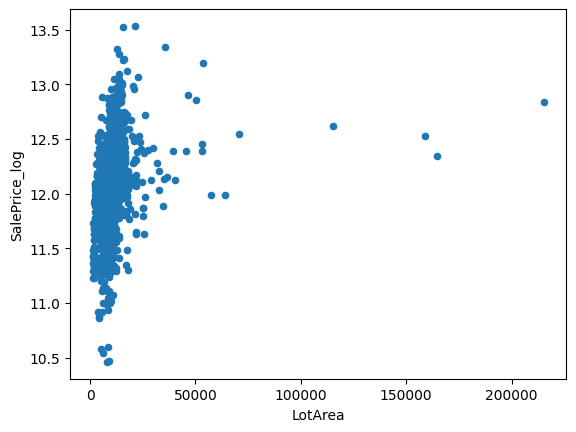

In [12]:
var = 'LotArea'
data = pd.concat([df_train['SalePrice_log'], df_train[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice_log')

*There’s a weak positive relationship overall — larger lot areas can be associated with higher sale prices, but the pattern is noisy.*   

So, I guess this is no good for our prediction.

### Relationship with categorical variables

After studying the relationship between the `SalesPrice` and the numercial variables, we now check the categorical variables:
- **OverallQual**
    - Overall material and finish quality (rated 1–10)
    - Strongest categorical predictor of SalePrice — higher quality consistently drives higher prices

- **YearBuilt**
    - Year the house was originally constructed
    - Older homes tend to sell for less unless well-maintained or renovated; newer builds often command premium prices

In [13]:
df_train['OverallQual'].unique()

array([ 7,  6,  8,  5,  9,  4, 10,  3,  1,  2])

In [14]:
df_train['YearBuilt'].unique()

array([2003, 1976, 2001, 1915, 2000, 1993, 2004, 1973, 1931, 1939, 1965,
       2005, 1962, 2006, 1960, 1929, 1970, 1967, 1958, 1930, 2002, 1968,
       2007, 1951, 1957, 1927, 1920, 1966, 1959, 1994, 1954, 1953, 1955,
       1983, 1975, 1997, 1934, 1963, 1981, 1964, 1999, 1972, 1921, 1945,
       1982, 1998, 1956, 1948, 1910, 1995, 1991, 2009, 1950, 1961, 1977,
       1985, 1979, 1885, 1919, 1990, 1969, 1935, 1988, 1971, 1952, 1936,
       1923, 1924, 1984, 1926, 1940, 1941, 1987, 1986, 2008, 1908, 1892,
       1916, 1932, 1918, 1912, 1947, 1925, 1900, 1980, 1989, 1992, 1949,
       1880, 1928, 1978, 1922, 1996, 2010, 1946, 1913, 1937, 1942, 1938,
       1974, 1893, 1914, 1906, 1890, 1898, 1904, 1882, 1875, 1911, 1917,
       1872, 1905])

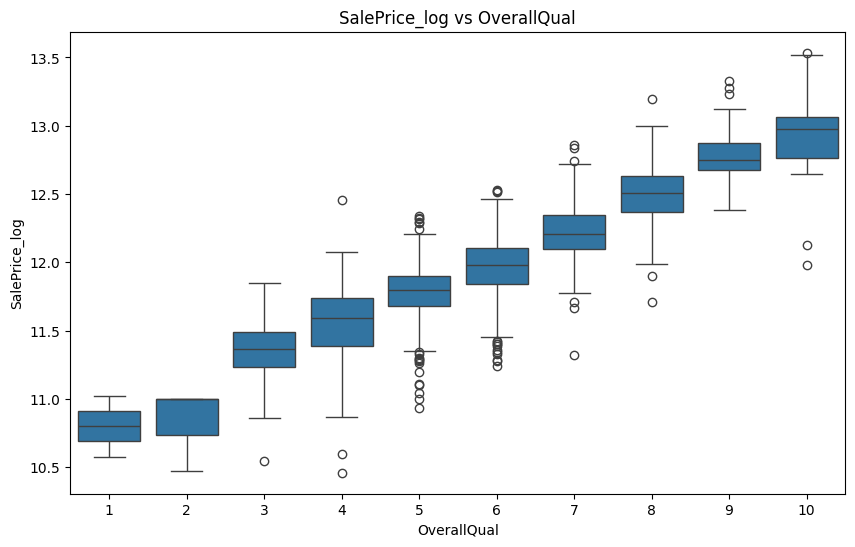

In [15]:
# Boxplot for OverallQual
var = 'OverallQual'
plt.figure(figsize=(10,6))
sns.boxplot(x=var, y='SalePrice_log', data=df_train)
plt.title("SalePrice_log vs OverallQual")
plt.show()

- **Strong upward trend:** As OverallQual increases from 1 to 10, the median SalePrice_log also increases steadily.     
- **Tight distributions at higher quality levels:** Higher OverallQual scores (7–10) show more consistent pricing, with fewer outliers.    
- **Wider spread at lower quality levels:** Lower scores (3–5) have more variability and outliers, suggesting less predictable pricing.   

`OverallQual` is a powerful categorical predictor — higher quality ratings consistently lead to higher sale prices, and the relationship is both strong and stable. This makes it a key feature for modeling.

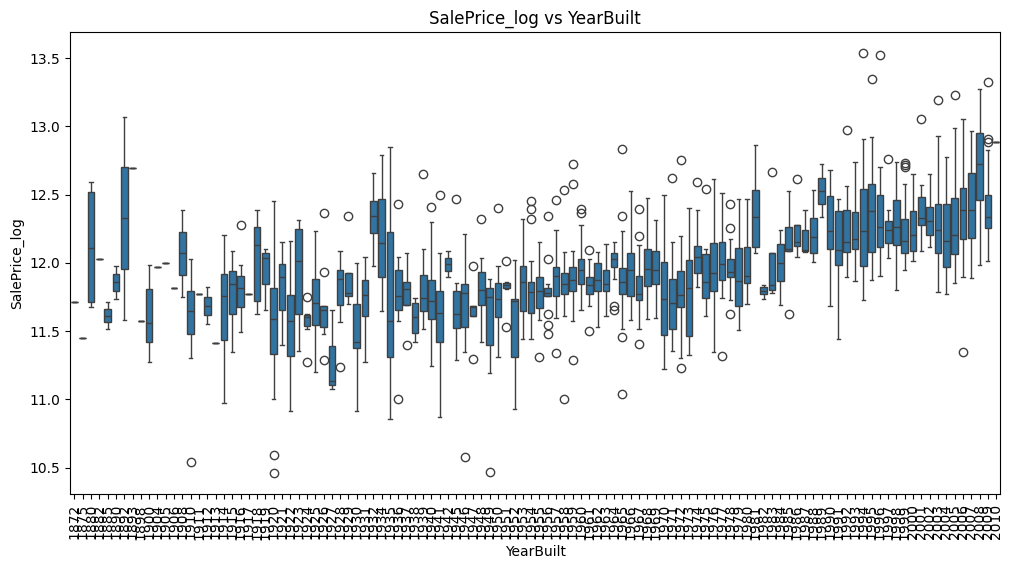

In [16]:
# Boxplot for YearBuilt (treated as categorical)
var = 'YearBuilt'
plt.figure(figsize=(12,6))
sns.boxplot(x=var, y='SalePrice_log', data=df_train)
plt.title("SalePrice_log vs YearBuilt")
plt.xticks(rotation=90)  # rotate labels if too crowded
plt.show()

- Newer homes tend to have higher sale prices  
- Price distributions are tighter for recently built houses  
- Older homes show more variability and outliers  
- YearBuilt is a meaningful predictor, but grouping by decade may improve clarity  


In [20]:
df_train.dtypes


Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
SalePrice_log    float64
Length: 82, dtype: object

In [ ]:
#correlation matrix
corrmat = df_train.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

AttributeError: 'DataFrame' object has no attribute 'dtype'

In [21]:
df_train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,12.247694
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,12.109011
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,12.317167
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,11.849398
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,12.429216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,8,2007,WD,Normal,175000,12.072541
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000,12.254863
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500,12.493130
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,4,2010,WD,Normal,142125,11.864462
